# Analyzing the Data

In [1]:
import pandas as pd

In [2]:
df = pd.read_excel("../Dataset/sample_-_superstore.xls", sheet_name="Orders")

In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,2023-01-05,2023-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


In [4]:
df.shape

(10194, 21)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          10194 non-null  int64         
 1   Order ID        10194 non-null  str           
 2   Order Date      10194 non-null  datetime64[us]
 3   Ship Date       10194 non-null  datetime64[us]
 4   Ship Mode       10194 non-null  str           
 5   Customer ID     10194 non-null  str           
 6   Customer Name   10194 non-null  str           
 7   Segment         10194 non-null  str           
 8   Country/Region  10194 non-null  str           
 9   City            10194 non-null  str           
 10  State/Province  10194 non-null  str           
 11  Postal Code     10194 non-null  object        
 12  Region          10194 non-null  str           
 13  Product ID      10194 non-null  str           
 14  Category        10194 non-null  str           
 15  Sub-Category 

In [6]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.describe()

,Row ID,Order Date,Ship Date,Sales,Quantity,Discount,Profit
count,10194.000000,10194,10194,10194.000000,10194.000000,10194.000000,10194.000000
mean,5097.500000,2025-04-29 11:48:25.002943,2025-05-03 10:52:45.626839,228.225854,3.791838,0.155385,28.673417
min,1.000000,2023-01-03 00:00:00,2023-01-07 00:00:00,0.444000,1.000000,0.000000,-6599.978000
25%,2549.250000,2024-05-14 00:00:00,2024-05-19 00:00:00,17.220000,2.000000,0.000000,1.760800
50%,5097.500000,2025-06-25 00:00:00,2025-06-28 00:00:00,53.910000,3.000000,0.200000,8.690000
75%,7645.750000,2026-05-14 00:00:00,2026-05-18 00:00:00,209.500000,5.000000,0.200000,29.297925
max,10194.000000,2026-12-30 00:00:00,2027-01-05 00:00:00,22638.480000,14.000000,0.800000,8399.976000
std,2942.898656,NaN,NaN,619.906839,2.228317,0.206249,232.465115


In [9]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City',
       'State/Province', 'Postal Code', 'Region', 'Product ID', 'Category',
       'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='str')

In [10]:
df.nunique()

Row ID            10194
Order ID           5111
Order Date         1242
Ship Date          1338
Ship Mode             4
Customer ID         804
Customer Name       800
Segment               3
Country/Region        2
City                542
State/Province       59
Postal Code         654
Region                4
Product ID         1862
Category              3
Sub-Category         17
Product Name       1849
Sales              6161
Quantity             14
Discount             12
Profit             7597
dtype: int64

In [11]:
df["Category"].unique()

<StringArray>
['Office Supplies', 'Furniture', 'Technology']
Length: 3, dtype: str

In [12]:
df["Segment"].unique()

<StringArray>
['Consumer', 'Home Office', 'Corporate']
Length: 3, dtype: str

In [13]:
df["Region"].unique()

<StringArray>
['Central', 'East', 'South', 'West']
Length: 4, dtype: str

In [14]:
df["Ship Mode"].unique()

<StringArray>
['Standard Class', 'First Class', 'Second Class', 'Same Day']
Length: 4, dtype: str

# Initial Business Analysis

In [15]:
#Which category generates the highest sales?
highest_sales_category = df.groupby("Category")["Sales"].sum()
print("The Highest Sales Category is: ", highest_sales_category)
print("The Highest Sales Category is: ", highest_sales_category.idxmax())
print("The Lowest Sales Category is: ", highest_sales_category.idxmin())

The Highest Sales Category is:  Category
Furniture          754747.7613
Office Supplies    731893.3140
Technology         839893.2790
Name: Sales, dtype: float64
The Highest Sales Category is:  Technology
The Lowest Sales Category is:  Office Supplies


In [16]:
#Which category generates the highest profit?
highest_profit_category = df.groupby("Category")["Profit"].sum()
print("The Highest Profit Category is: ", highest_profit_category)
print("The Highest Profit Category is: ", highest_profit_category.idxmax())
print("The Lowest Profit Category is: ", highest_profit_category.idxmin())

The Highest Profit Category is:  Category
Furniture           19729.9956
Office Supplies    126023.4434
Technology         146543.3756
Name: Profit, dtype: float64
The Highest Profit Category is:  Technology
The Lowest Profit Category is:  Furniture


In [17]:
#Which region generates the highest sales?
highest_sales_region = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)
print("The Highest Sales Region is:\n", highest_sales_region)
print("The Highest Sales Region is: ", highest_sales_region.idxmax())
print("Lowest Sales Region is: ", highest_sales_region.idxmin())

The Highest Sales Region is:
 Region
West       739813.6085
East       691828.1680
Central    503170.6728
South      391721.9050
Name: Sales, dtype: float64
The Highest Sales Region is:  West
Lowest Sales Region is:  South


Investigate why the West performs so well and replicate those strategies in lower-performing regions like the South.

In [18]:
#Does the West sell more Technology products?

# sales_by_region_category = df.groupby(["Region", "Category"])["Sales"].sum()
# print(sales_by_region_category)
# print(f"\nHighest Sales Region for each Category: \n{sales_by_region_category.groupby('Category').idxmax()}")

sales_by_region_category = df.groupby(["Region", "Category"])["Sales"].sum()
print(sales_by_region_category)
print("\nHighest Sales Region for each Category:")
for category in df["Category"].unique():
    region = sales_by_region_category.xs(category, level="Category").idxmax()
    print(f"{category}: {region}")

Region   Category       
Central  Furniture          164537.6518
         Office Supplies    168216.7090
         Technology         170416.3120
East     Furniture          212231.6960
         Office Supplies    211658.4010
         Technology         267938.0710
South    Furniture          117298.6840
         Office Supplies    125651.3130
         Technology         148771.9080
West     Furniture          260679.7295
         Office Supplies    226366.8910
         Technology         252766.9880
Name: Sales, dtype: float64

Highest Sales Region for each Category:
Office Supplies: West
Furniture: West
Technology: East


In [19]:
#Does the West have more customers? or Count unique customers by region
more_customers = df.groupby("Region")["Customer ID"].nunique()
print(f"Customer count by region:\n{more_customers}")

#Does the West have the largest customer base?
print(f"\nRegion with the largest customer base: {more_customers.idxmax()}")

Customer count by region:
Region
Central    629
East       685
South      512
West       686
Name: Customer ID, dtype: int64

Region with the largest customer base: West


In [20]:
#Does the West give lower discounts?
region_discounts = df.groupby("Region")["Discount"].mean()
print(region_discounts)

#Is the West more profitable because it gives lower discounts?
print(f"\nRegion with the highest average profit: {df.groupby('Region')['Profit'].mean().idxmax()}")

#Is the West more profitable because it gives lower discounts?
west = df[df["Region"] == "West"]
print(f"\nCorrelation between Discount and Profit in the West: {west[['Discount', 'Profit']].corr().iloc[0, 1]}")

Region
Central    0.241002
East       0.143436
South      0.147253
West       0.108946
Name: Discount, dtype: float64

Region with the highest average profit: West

Correlation between Discount and Profit in the West: -0.15465562432838906


In [21]:
#Does the West earn more profit from each category?
more_profit=df.groupby(["Region", "Category"])["Profit"].sum()
print(more_profit)

#Which categories make the West the most profitable region?
west_category_profit = more_profit.xs("West", level="Region")
print(west_category_profit)
print(f"\nHighest Profit Category in the West: {west_category_profit.idxmax()}")

Region   Category       
Central  Furniture          -2802.2067
         Office Supplies     8970.0817
         Technology         33697.4320
East     Furniture           3444.7448
         Office Supplies    42996.7397
         Technology         48441.7758
South    Furniture           6771.2061
         Office Supplies    19986.3928
         Technology         19991.8314
West     Furniture          12316.2514
         Office Supplies    54070.2292
         Technology         44412.3364
Name: Profit, dtype: float64
Category
Furniture          12316.2514
Office Supplies    54070.2292
Technology         44412.3364
Name: Profit, dtype: float64

Highest Profit Category in the West: Office Supplies


In [22]:
#Which region generates the highest profit?
highest_profit_region = df.groupby("Region")["Profit"].sum().sort_values(ascending=False)
print("The Highest Profit Region is:\n", highest_profit_region)
print("The Highest Profit Region is: ", highest_profit_region.idxmax())

The Highest Profit Region is:
 Region
West       110798.8170
East        94883.2603
South       46749.4303
Central     39865.3070
Name: Profit, dtype: float64
The Highest Profit Region is:  West


In [23]:
#Study the West region's pricing, product mix, and customer behavior, then apply successful strategies to other regions.
# Compare average discount by region
df.groupby("Region")["Discount"].mean()

Region
Central    0.241002
East       0.143436
South      0.147253
West       0.108946
Name: Discount, dtype: float64

In [24]:
# Compare profit by category in each region
profit_by_category = df.groupby(["Region","Category"])["Profit"].sum()
print(profit_by_category)

#which categories sell more and earn more profit.
print(f"\nHighest Profit Category in each Region:\n{profit_by_category.groupby('Region').idxmax()}")

Region   Category       
Central  Furniture          -2802.2067
         Office Supplies     8970.0817
         Technology         33697.4320
East     Furniture           3444.7448
         Office Supplies    42996.7397
         Technology         48441.7758
South    Furniture           6771.2061
         Office Supplies    19986.3928
         Technology         19991.8314
West     Furniture          12316.2514
         Office Supplies    54070.2292
         Technology         44412.3364
Name: Profit, dtype: float64

Highest Profit Category in each Region:
Region
Central      (Central, Technology)
East            (East, Technology)
South          (South, Technology)
West       (West, Office Supplies)
Name: Profit, dtype: object


In [25]:
#Which Sub-Category generates the highest sales?
subcategory_sales = df.groupby("Sub-Category")["Sales"].sum().sort_values(ascending=False)
print(f"Sales by Sub-Category:\n{subcategory_sales}")
print(f"\nHighest Sales Sub-Category: {subcategory_sales.idxmax()}")
print(f"Lowest Sales Sub-Category: {subcategory_sales.idxmin()}")

Sales by Sub-Category:
Sub-Category
Chairs         335768.2490
Phones         331842.6400
Storage        224644.5540
Tables         208020.1820
Binders        207354.8810
Machines       189925.0310
Accessories    167380.3180
Copiers        150745.2900
Bookcases      115361.2043
Appliances     108213.1850
Furnishings     95598.1260
Paper           79540.5380
Supplies        46725.4980
Art             27659.0140
Envelopes       16528.3620
Labels          12695.0420
Fasteners        8532.2400
Name: Sales, dtype: float64

Highest Sales Sub-Category: Chairs
Lowest Sales Sub-Category: Fasteners


# Exploratory Data Analysis (EDA).

## Sub-Category Analysis

In [26]:
#Which Sub-Category generates the highest profit?
subcategory_profit = df.groupby("Sub-Category")["Profit"].sum().sort_values(ascending=False)
print(f"Profit by Sub-Category:\n{subcategory_profit}")
print(f"\nHighest Profit Sub-Category: {subcategory_profit.idxmax()}")
print(f"Lowest Profit Sub-Category: {subcategory_profit.idxmin()}")

Profit by Sub-Category:
Sub-Category
Copiers        56093.9365
Phones         45050.8265
Accessories    41936.6357
Paper          34511.5070
Binders        31426.1003
Chairs         27223.5323
Storage        21285.1115
Appliances     18329.4844
Furnishings    13891.7430
Envelopes       6988.0247
Art             6653.1962
Labels          5572.7780
Machines        3461.9769
Fasteners       2428.6358
Supplies       -1171.3945
Bookcases      -3632.0736
Tables        -17753.2061
Name: Profit, dtype: float64

Highest Profit Sub-Category: Copiers
Lowest Profit Sub-Category: Tables


## Top Products Analysis

In [27]:
#Which are the Top 10 Products by Sales? use for loop to print the values before the product names
top_products_sales = (
    df.groupby("Product Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)
top_products_sales.index = top_products_sales.index + 1
print(top_products_sales)

                                         Product Name      Sales
1               Canon imageCLASS 2200 Advanced Copier  61599.824
2   Fellowes PB500 Electric Punch Plastic Comb Bin...  27453.384
3   Cisco TelePresence System EX90 Videoconferenci...  22638.480
4        HON 5400 Series Task Chairs for Big and Tall  21870.576
5          GBC DocuBind TL300 Electric Binding System  19823.479
6    GBC Ibimaster 500 Manual ProClick Binding System  19024.500
7                Hewlett Packard LaserJet 3310 Copier  18839.686
8   HP Designjet T520 Inkjet Large Format Printer ...  18374.895
9           GBC DocuBind P400 Electric Binding System  17965.068
10        High Speed Automatic Electric Letter Opener  17030.312


In [28]:
#Which are the Top 10 Products by Profit?
top_products_profit = (
    df.groupby("Product Name")["Profit"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)
top_products_profit.index = top_products_profit.index + 1
print(top_products_profit)

                                         Product Name      Profit
1               Canon imageCLASS 2200 Advanced Copier  25199.9280
2   Fellowes PB500 Electric Punch Plastic Comb Bin...   7753.0390
3                Hewlett Packard LaserJet 3310 Copier   6983.8836
4                  Canon PC1060 Personal Laser Copier   4570.9347
5   HP Designjet T520 Inkjet Large Format Printer ...   4094.9766
6                   Ativa V4110MDD Micro-Cut Shredder   3772.9461
7    3D Systems Cube Printer, 2nd Generation, Magenta   3717.9714
8   Plantronics Savi W720 Multi-Device Wireless He...   3696.2820
9                Ibico EPK-21 Electric Binding System   3345.2823
10                  Zebra ZM400 Thermal Label Printer   3343.5360


In [29]:
#product_summary = df.groupby("Product Name")[["Sales", "Profit"]].sum()
#product_summary = product_summary.sort_values(by="Sales", ascending=False)
#print(product_summary.head(10))

product_summary = (
    df.groupby("Product Name")[["Sales", "Profit"]]
      .sum()
      .sort_values(by="Sales", ascending=False)
      .head(10)
      .reset_index()
)
product_summary.index = product_summary.index + 1
# print(product_summary)
display(product_summary)

,Product Name,Sales,Profit
1,Canon imageCLASS 2200 Advanced Copier,61599.824,2.519993e+04
2,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.384,7.753039e+03
3,Cisco TelePresence System EX90 Videoconferenci...,22638.480,-1.811078e+03
4,HON 5400 Series Task Chairs for Big and Tall,21870.576,3.410605e-13
5,GBC DocuBind TL300 Electric Binding System,19823.479,2.233505e+03
6,GBC Ibimaster 500 Manual ProClick Binding System,19024.500,7.609800e+02
7,Hewlett Packard LaserJet 3310 Copier,18839.686,6.983884e+03
8,HP Designjet T520 Inkjet Large Format Printer ...,18374.895,4.094977e+03
9,GBC DocuBind P400 Electric Binding System,17965.068,-1.878166e+03
10,High Speed Automatic Electric Letter Opener,17030.312,-2.620048e+02


# Customers Analysis

In [30]:
#Which customers generate the highest sales?
top_customers = (
    df.groupby("Customer Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)
top_customers.index = top_customers.index + 1
top_customers

,Customer Name,Sales
1,Sean Miller,25043.050
2,Tamara Chand,19052.218
3,Raymond Buch,15117.339
4,Tom Ashbrook,14595.620
5,Adrian Barton,14473.571
6,Ken Lonsdale,14175.229
7,Sanjit Chand,14142.334
8,Hunter Lopez,12873.298
9,Sanjit Engle,12209.438
10,Christopher Conant,12129.072


In [31]:
#Who are the Top 10 customers by Profit?
top_profit_customers = (
    df.groupby("Customer Name")["Profit"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)
top_profit_customers.index = top_profit_customers.index + 1
top_profit_customers

,Customer Name,Profit
1,Tamara Chand,8981.3239
2,Raymond Buch,6976.0959
3,Sanjit Chand,5757.4119
4,Hunter Lopez,5622.4292
5,Adrian Barton,5444.8055
6,Tom Ashbrook,4703.7883
7,Christopher Martinez,3899.8904
8,Keith Dawkins,3038.6254
9,Andy Reiter,2884.6208
10,Daniel Raglin,2869.0760


In [32]:
#Do the customers with the highest sales also generate the highest profit?
comparison = (
    df.groupby("Customer Name")[["Sales", "Profit"]]
      .sum()
      .sort_values(by="Sales", ascending=False)
      .head(10)
      .reset_index()
)
comparison.index = comparison.index + 1
comparison

,Customer Name,Sales,Profit
1,Sean Miller,25043.050,-1980.7393
2,Tamara Chand,19052.218,8981.3239
3,Raymond Buch,15117.339,6976.0959
4,Tom Ashbrook,14595.620,4703.7883
5,Adrian Barton,14473.571,5444.8055
6,Ken Lonsdale,14175.229,806.8550
7,Sanjit Chand,14142.334,5757.4119
8,Hunter Lopez,12873.298,5622.4292
9,Sanjit Engle,12209.438,2650.6769
10,Christopher Conant,12129.072,2177.0493


## Time Series Analysis

In [33]:
#How do Sales change over time?
monthly_sales = (
    df.groupby(df["Order Date"].dt.to_period("M"))["Sales"]
      .sum()
)
# print(monthly_sales)
print(f"\nHighest Sales Month: {monthly_sales.idxmax()}")
print(f"Highest Sales Value: ${monthly_sales.max():,.2f}")
print(f"\nLowest Sales Month: {monthly_sales.idxmin()}")
print(f"Lowest Sales Value: ${monthly_sales.min():,.2f}")


Highest Sales Month: 2026-11
Highest Sales Value: $118,454.51

Lowest Sales Month: 2023-02
Lowest Sales Value: $4,519.89


Investigate why November performs so well (seasonal demand, promotions, holidays). 
Plan inventory before November

In [34]:
#Check Sales by Category in November
november = df[df["Order Date"].dt.month == 11]
november.groupby("Category")["Sales"].sum().sort_values(ascending=False)

Category
Technology         131134.841
Furniture          121484.289
Office Supplies    100046.861
Name: Sales, dtype: float64

In [35]:
#Check Sales by Region in November
november.groupby("Region")["Sales"].sum().sort_values(ascending=False)

Region
East       137496.1800
West        90605.3125
Central     65025.9490
South       59538.5495
Name: Sales, dtype: float64

In [36]:
#Check Top 10 Products in November
november.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          10499.970
Cubify CubeX 3D Printer Triple Head Print                                       7999.980
DMI Eclipse Executive Suite Bookcases                                           7414.504
Zebra ZM400 Thermal Label Printer                                               6965.700
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind     4575.564
Apple iPhone 5                                                                  4548.810
Cubify CubeX 3D Printer Double Head Print                                       4499.985
Riverside Palais Royal Lawyers Bookcase, Royale Cherry Finish                   4404.900
GBC DocuBind TL300 Electric Binding System                                      4395.251
Global Troy Executive Leather Low-Back Tilter                                   4007.840
Name: Sales, dtype: float64

Why is February so weak?

In [37]:
#Check Sales by Category in February
february = df[df["Order Date"].dt.month == 2]
february.groupby("Category")["Sales"].sum().sort_values(ascending=False)

Category
Technology         23343.4180
Office Supplies    20641.9130
Furniture          15765.9204
Name: Sales, dtype: float64

In [38]:
# Check Sales by Region in February
february.groupby("Region")["Sales"].sum().sort_values(ascending=False)

Region
South      20981.4760
West       15777.2130
East       14781.2520
Central     8211.3104
Name: Sales, dtype: float64

In [39]:
# Check Top Products in February
february.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)

Product Name
HP Designjet T520 Inkjet Large Format Printer - 24" Color                                8749.950
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind              2541.980
Sanyo Counter Height Refrigerator with Crisper, 3.6 Cubic Foot, Stainless Steel/Black    1640.700
Tennsco Double-Tier Lockers                                                              1350.120
Plantronics CS510 - Over-the-Head monaural Wireless Headset System                       1319.800
Office Star - Contemporary Swivel Chair with Padded Adjustable Arms and Flex Back        1268.820
Hon 2111 Invitation Series Corner Table                                                  1256.220
Kensington 7 Outlet MasterPiece Power Center                                             1245.860
Toshiba IPT2010-SD IP Telephone                                                          1223.112
Samsung Galaxy S4 Mini                                                                   1127.976
Name: S

# First Visualization

### Monthly Sales Trend

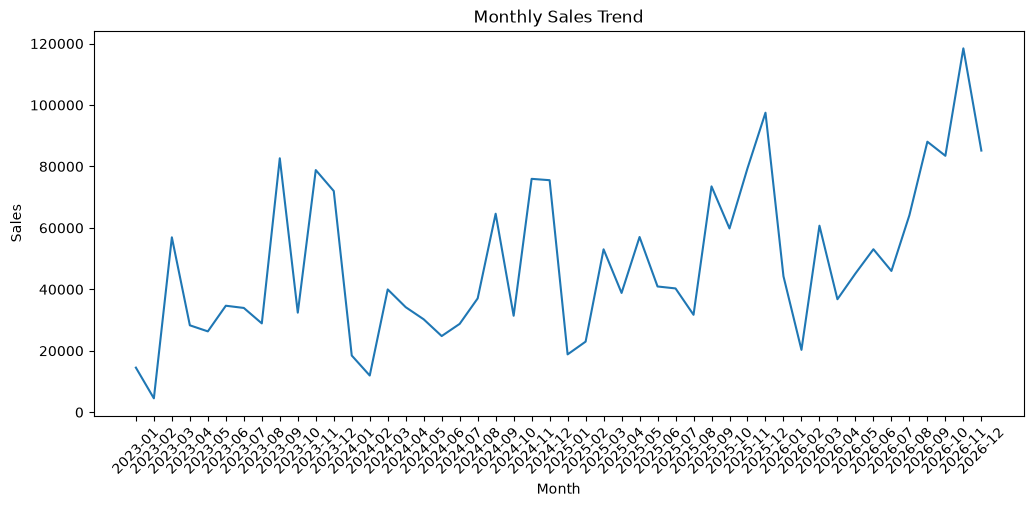

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(monthly_sales.index.astype(str), monthly_sales.values)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.show()

### Monthly Profit Trend

In [ ]:
#How does profit change over time?
monthly_profit = (
    df.groupby(df["Order Date"].dt.to_period("M"))["Profit"]
      .sum()
)

monthly_profit
print(f"Highest Profit Month: {monthly_profit.idxmax()}")
print(f"Highest Profit: ${monthly_profit.max():,.2f}")

print(f"\nLowest Profit Month: {monthly_profit.idxmin()}")
print(f"Lowest Profit: ${monthly_profit.min():,.2f}")

Highest Profit Month: 2025-12
Highest Profit: $17,926.30

Lowest Profit Month: 2024-01
Lowest Profit: $-3,189.80


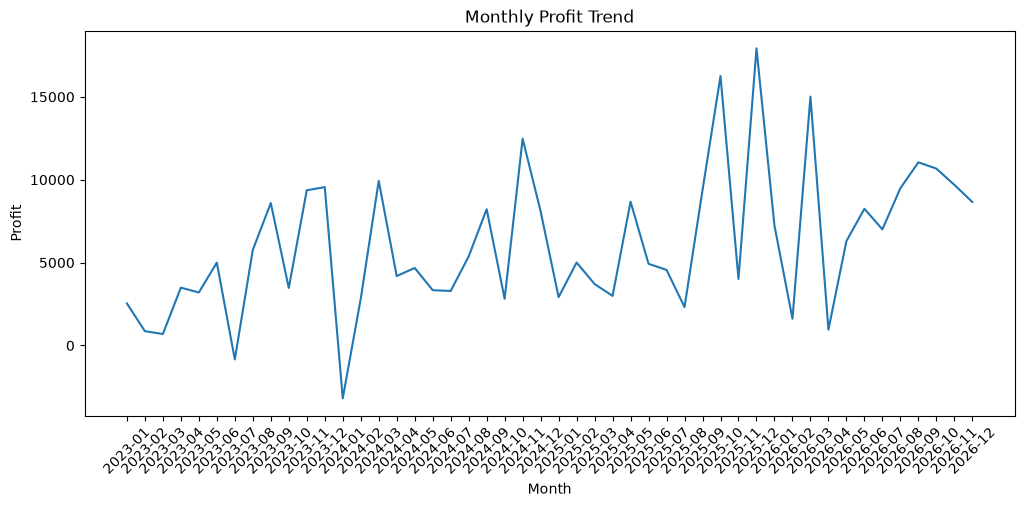

In [45]:
#the profit trend graph.
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(monthly_profit.index.astype(str), monthly_profit.values)

plt.title("Monthly Profit Trend")
plt.xlabel("Month")
plt.ylabel("Profit")

plt.xticks(rotation=45)

plt.show()

In [47]:
#How has the business grown year by year?
yearly_summary = (
    df.groupby(df["Order Date"].dt.year)[["Sales", "Profit"]]
      .sum()
)

yearly_summary

,Sales,Profit
Order Date,,
2023,494040.2121,51684.2957
2024,472993.0310,62020.9695
2025,613933.5800,82665.2018
2026,745567.5312,95926.3476


### Yearly Sales & Profit Analysis

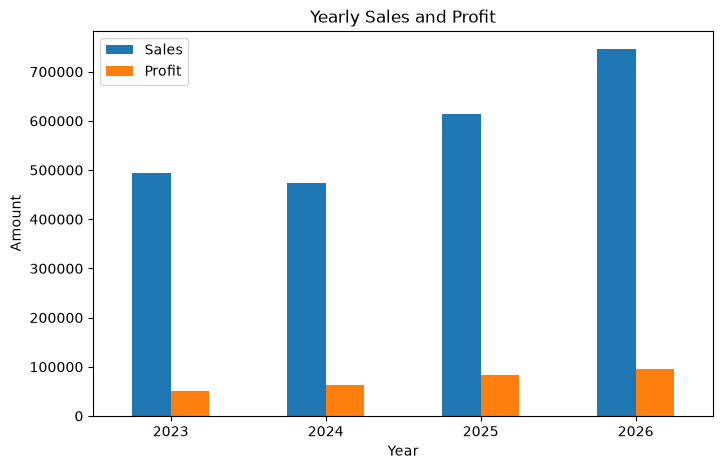

In [48]:
#Yearly Sales & Profit
import matplotlib.pyplot as plt

yearly_summary.plot(kind="bar", figsize=(8,5))

plt.title("Yearly Sales and Profit")
plt.xlabel("Year")
plt.ylabel("Amount")

plt.xticks(rotation=0)

plt.show()

# Shipping Analysis

In [49]:
#Which shipping mode is used the most?
shipping_count = df["Ship Mode"].value_counts()
print(shipping_count)
print(f"\nMost Used Shipping Mode: {shipping_count.idxmax()}")
print(f"Least Used Shipping Mode: {shipping_count.idxmin()}")

Ship Mode
Standard Class    6120
Second Class      1979
First Class       1548
Same Day           547
Name: count, dtype: int64

Most Used Shipping Mode: Standard Class
Least Used Shipping Mode: Same Day


In [50]:
#Which shipping mode is the most profitable?
shipping_profit = df.groupby("Ship Mode")["Profit"].sum().sort_values(ascending=False)
print(shipping_profit)
print(f"\nMost Profitable Shipping Mode: {shipping_profit.idxmax()}")
print(f"Least Profitable Shipping Mode: {shipping_profit.idxmin()}")

Ship Mode
Standard Class    168161.2095
Second Class       58962.1329
First Class        49012.7242
Same Day           16160.7480
Name: Profit, dtype: float64

Most Profitable Shipping Mode: Standard Class
Least Profitable Shipping Mode: Same Day


In [52]:
#How long does each shipping mode take?
df["Shipping Time"] = (df["Ship Date"] - df["Order Date"]).dt.days
df[["Order Date", "Ship Date", "Ship Mode", "Shipping Time"]].head()

,Order Date,Ship Date,Ship Mode,Shipping Time
0,2023-01-03,2023-01-07,Standard Class,4
1,2023-01-04,2023-01-08,Standard Class,4
2,2023-01-04,2023-01-08,Standard Class,4
3,2023-01-04,2023-01-08,Standard Class,4
4,2023-01-05,2023-01-12,Standard Class,7


In [53]:
shipping_time = df.groupby("Ship Mode")["Shipping Time"].mean().sort_values()

print(shipping_time)

Ship Mode
Same Day          0.043876
First Class       2.182171
Second Class      3.237999
Standard Class    4.995425
Name: Shipping Time, dtype: float64


In [54]:
df.groupby("Ship Mode")["Shipping Time"].value_counts().sort_index()

Ship Mode       Shipping Time
First Class     1                 344
                2                 579
                3                 624
                4                   1
Same Day        0                 523
                1                  24
Second Class    1                   1
                2                 782
                3                 380
                4                 377
                5                 439
Standard Class  3                  21
                4                2460
                5                1804
                6                1204
                7                 629
                11                  2
Name: count, dtype: int64

In [55]:
late_orders = df[df["Shipping Time"] > 7]

late_orders[["Order ID", "Customer Name", "Region", "Ship Mode", "Shipping Time"]]

,Order ID,Customer Name,Region,Ship Mode,Shipping Time
1698,CA-2023-153623,James Peterman,East,Standard Class,11
1699,CA-2023-153623,James Peterman,East,Standard Class,11


# Discount Analysis

In [58]:
#As the discount increases, what happens to average Sales and average Profit?
discount_analysis = (
    df.groupby("Discount")[["Sales", "Profit"]]
      .mean()
      .sort_index()
)

print(discount_analysis)
best_discount = discount_analysis["Profit"].idxmax()

print(f"Best Discount (Sweet Spot): {best_discount:.0%}")
print(f"Average Sales: {discount_analysis.loc[best_discount, 'Sales']:.2f}")
print(f"Average Profit: {discount_analysis.loc[best_discount, 'Profit']:.2f}")

               Sales      Profit
Discount                        
0.00      224.431226   66.338799
0.10      572.421844   94.791354
0.15      529.971567   27.288298
0.20      208.834160   24.576350
0.30      454.235074  -45.710633
0.32      536.794770  -88.560656
0.40      562.791101 -111.528378
0.45      498.634000 -226.646464
0.50      892.705152 -310.703456
0.60       47.690872  -41.371458
0.70       96.238835  -95.048521
0.80       56.412445 -101.545745
Best Discount (Sweet Spot): 10%
Average Sales: 572.42
Average Profit: 94.79


# Correlation Heatmap

In [59]:
correlation = df.select_dtypes(include=["number"]).corr()
correlation

,Row ID,Sales,Quantity,Discount,Profit,Shipping Time
Row ID,1.000000,-0.008958,0.000502,-0.001474,0.003022,-0.020459
Sales,-0.008958,1.000000,0.198457,-0.027756,0.481460,-0.006921
Quantity,0.000502,0.198457,1.000000,0.007475,0.066145,0.021068
Discount,-0.001474,-0.027756,0.007475,1.000000,-0.218882,-0.001774
Profit,0.003022,0.481460,0.066145,-0.218882,1.000000,-0.004350
Shipping Time,-0.020459,-0.006921,0.021068,-0.001774,-0.004350,1.000000


In [61]:
# correlation.unstack().sort_values(ascending=False)
corr = correlation.unstack().sort_values(ascending=False)

corr = corr[(corr < 1) & (corr > -1)]

print(corr.head(10))

Sales          Profit           0.481460
Profit         Sales            0.481460
Quantity       Sales            0.198457
Sales          Quantity         0.198457
Profit         Quantity         0.066145
Quantity       Profit           0.066145
               Shipping Time    0.021068
Shipping Time  Quantity         0.021068
Quantity       Discount         0.007475
Discount       Quantity         0.007475
dtype: float64


In [62]:
print(corr.tail(10))

Shipping Time  Sales           -0.006921
Sales          Shipping Time   -0.006921
Row ID         Sales           -0.008958
Sales          Row ID          -0.008958
Row ID         Shipping Time   -0.020459
Shipping Time  Row ID          -0.020459
Discount       Sales           -0.027756
Sales          Discount        -0.027756
Profit         Discount        -0.218882
Discount       Profit          -0.218882
dtype: float64


# Export the Cleaned Data

In [63]:
df.to_csv("Superstore_Cleaned.csv", index=False)

print("Dataset exported successfully!")

Dataset exported successfully!
